## Entrained volume and entrainment speed

In [1]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from functions import apply_filters

# Use given style and color maps
from colors import colors7 as colors

plt.style.use("james2026lock.mplstyle")

# constants
rho_water = 998.2  # Freshwater density [kg/m³]
rho_bent = 2277  # Wetted bentonite density [kg/m³]
h0 = 0.25  # initial water height [m]
l0 = 0.27  # mixing chamber length [m]
v0 = h0 * l0
a_thresh = 0.06  # m/s² for example (below this velocity taken as roughly constant)

# load experiment table
metadata = pd.read_csv("../../data/metadata/metadata.csv")
folder = "../../data/datafiles"

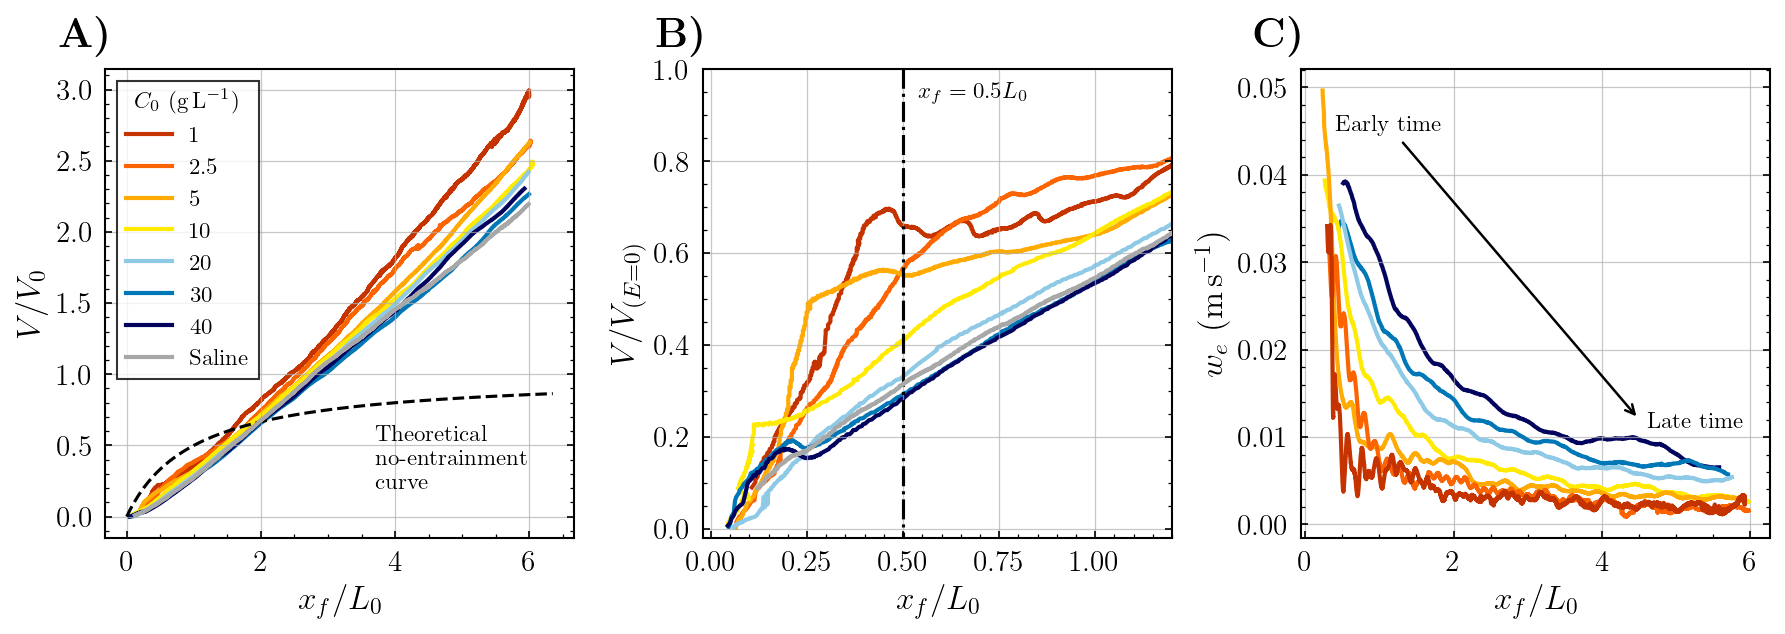

In [2]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))


def moving_average(a, w):
    """Smooth array a with a boxcar window of width w."""
    return np.convolve(a, np.ones(w) / w, mode="valid")


WINDOW = 120  # smoothing window for w_e calculation
T_CROP = 2.5  # seconds to crop from start to remove edge effects

# --- Filter sets: particle experiments and saline baseline ---
filter_part = {"cont": ["none", "stop"], "mixing": "stagnation low Q", "type": ["part"]}
filter_sal = {"cont": ["none", "stop"], "mixing": "none", "type": ["saline"]}


def load_exp(row):
    """Load and return absolute-valued data arrays for one experiment."""
    data = np.load(f"{folder}/{row.exp_code}.npy", allow_pickle=True).item()
    return (np.abs(data[k]) for k in ["area_m2", "front_m", "time_s", "xcenters"])


def plot_part_exp(row):
    """Compute volume and entrainment diagnostics and plot across all 3 panels."""
    areas, fronts, times, _ = load_exp(row)

    c = colors[int(row.exp_code[2]) - 1]
    lw = 2
    lbl = f"{row.C0:.2g}"

    # Normalised front position and theoretical volume (no entrainment)
    xf = fronts / l0
    v0 = l0 * h0
    v_th = (v0 / (l0 + fronts)) * fronts  # V expected if E=0

    # Panel 0: raw area normalised by initial volume
    ax[0].plot(xf, areas / v0, color=c, linewidth=lw, label=lbl, zorder=1)

    # Panel 1: area normalised by theoretical (no-entrainment) volume
    ax[1].plot(xf, areas / v_th, color=c, linewidth=lw, zorder=1)

    x = moving_average(fronts, WINDOW)
    A = moving_average(areas, WINDOW)
    t = moving_average(times, WINDOW)

    U = np.diff(x) / np.diff(t)  # front velocity
    dAdx = np.diff(A) / np.diff(x)  # area gradient w.r.t. front position
    w_e = (U / x[1:]) * dAdx  # entrainment velocity

    mask = t[1:] > T_CROP  # remove edge effects
    ax[2].plot(
        x[1:][mask] / l0,
        w_e[mask],
        color=c,
        linewidth=lw,
        label=lbl,
        zorder=abs(7 - int(row.exp_code[2]) + 1),
    )


# --- Plot particle experiments ---
for _, row in apply_filters(metadata, filter_part).sort_values("rho").iterrows():
    plot_part_exp(row)

# --- Overlay theoretical no-entrainment curve on panel 0 ---
xf_th = np.linspace(0, ax[0].get_xlim()[1], 300)  # normalised front positions
v_th_curve = xf_th / (1 + xf_th)

ax[0].plot(xf_th, v_th_curve, color="k", linewidth=1.5, linestyle="--")
ax[0].text(
    3.7,
    0.4,
    "Theoretical\nno-entrainment\ncurve",
    fontsize=11,
    va="center",
    ha="left",
)

# --- Plot saline experiment with code NM2 ---
for _, row in apply_filters(metadata, filter_sal).iterrows():
    if row.exp_code != "NM2s":
        continue
    areas, fronts, times, _ = load_exp(row)

    c = "#a8a8a8"
    lw = 2
    lbl = "Saline"

    # Normalised front position and theoretical volume (no entrainment)
    xf = fronts / l0
    v0 = l0 * h0
    v_th = (v0 / (l0 + fronts)) * fronts  # V expected if E=0

    # Panel 0: raw area normalised by initial volume
    ax[0].plot(xf, areas / v0, color=c, linewidth=lw, label=lbl, zorder=5)
    # Panel 1: area normalised by theoretical (no-entrainment) volume
    ax[1].plot(xf, areas / v_th, color=c, linewidth=lw, zorder=5)


# --- Axes formatting ---
ax[0].legend(title="$C_0$ (g\\,L$^{-1}$)", fontsize=11, title_fontsize=11)
ax[0].set(xlabel="$x_f / L_0$", ylabel="$V/V_0$")

ax[1].set(
    xlim=[-0.02, 1.2],
    ylim=[-0.02, 1],
    xlabel="$x_f / L_0$",
    ylabel="$V/V_{(E=0)}$",
)
ax[1].vlines(0.5, -0.05, 1.2, colors="k", linestyles="-.", linewidth=1.5)
ax[1].text(
    0.54,
    0.95,
    "$x_f = 0.5L_0$",
    fontsize=11,
    va="center",
    ha="left",
)

ax[2].set(xlabel="$x_f / L_0$", ylabel="$w_e$ (m\\,s$^{-1}$)")

# --- Panel 0 annotations: early/late time with arrow ---
ax[2].annotate("Late time", xy=(4.6, 0.011), fontsize=11)
ax[2].annotate(
    "Early time",
    xy=(4.5, 0.012),
    xytext=(0.4, 0.045),
    arrowprops=dict(arrowstyle="->", color="k", lw=1.2),
    fontsize=11,
)

# ============== Labels ==============
for axis, label in zip(ax, ["\\textbf{A)}", "\\textbf{B)}", "\\textbf{C)}"]):
    axis.set_box_aspect(1)
    axis.annotate(
        label,
        xy=(-0.1, 1.05),
        xycoords="axes fraction",
        fontsize=20,
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig(
    "../figures/figure_12.pdf", format="pdf", bbox_inches="tight", facecolor="white"
)
plt.show()